In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_root = Path('/astrum/home/hpchzy/code/data/')
# date_base = '20260423'
date_base = '20260512'



# hostname = 'camd9554n2'
# hostname = 'cgnr6760pn2'
hostname = 'c920bn3'

kernel = "jacobi2d5p"
# kernel = "tl_f90_cg_calc_w"

output = 'output_sampOpt_filtOpt'
data_path = data_root / f'{date_base}/{hostname}/{output}'

freq_dict = {'camd9554n2': 3.1, 'cgnr6760pn2': 2.2, 'c920bn3': 2.9}


# Filt data

tm_hist_df


,ns,pr,cdf
0,1980,0.005048,0.005048
1,6700,0.005115,0.010163
2,8220,0.006093,0.016256
3,8780,0.005131,0.021387
4,9100,0.006283,0.027670


tf_hist_df


,ns,cnt,pr,cdf
0,1030,2,1.528865e-07,1.528865e-07
1,1040,36,2.751957e-06,2.904843e-06
2,1041,4,3.057730e-07,3.210616e-06
3,1050,340,2.599070e-05,2.920132e-05
4,1051,33,2.522627e-06,3.172395e-05


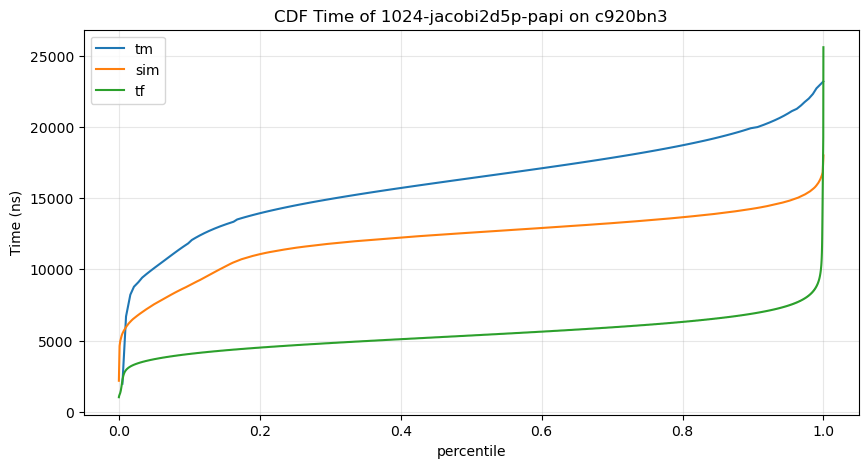

In [3]:
iarr = 1024
timer = 'papi'

filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_filt'

tm_hist_df = pd.read_csv(filt_folder_path / 'tm_hist.csv', header=None)
tm_hist_df.columns = ['ns', 'pr']
tm_hist_df['ns'] = pd.to_numeric(tm_hist_df['ns'], errors='coerce')
tm_hist_df['pr'] = pd.to_numeric(tm_hist_df['pr'], errors='coerce')
tm_hist_df = (
    tm_hist_df.dropna(subset=['ns', 'pr'])
    .loc[lambda d: d['pr'] > 0.0]
    .sort_values('ns', kind='stable')
    .reset_index(drop=True)
)
tm_hist_df['cdf'] = tm_hist_df['pr'].cumsum()
# tm_hist_df = tm_hist_df[tm_hist_df['cdf'] <= 0.995]

sim_hist_df = pd.read_csv(filt_folder_path / 'sim_cdf.csv', header=None)
sim_hist_df.columns = ['idx','sim_cdf', 'wasserstein', '%wasserstein']
sim_hist_df['cdf'] = sim_hist_df['idx'] / sim_hist_df.index.max()
# sim_hist_df = sim_hist_df[sim_hist_df['cdf'] <= 0.995]

tf_df = pd.read_csv(filt_folder_path / 'tf.csv', header=None)
tf_df.columns = ['ns']
tf_df['ns'] = pd.to_numeric(tf_df['ns'], errors='coerce')
tf_hist_df = (
    tf_df.dropna(subset=['ns'])
    .groupby('ns', as_index=False)
    .size()
    .rename(columns={'size': 'cnt'})
    .sort_values('ns', kind='stable')
    .reset_index(drop=True)
)
tf_hist_df['pr'] = tf_hist_df['cnt'] / tf_hist_df['cnt'].sum()
tf_hist_df['cdf'] = tf_hist_df['pr'].cumsum()
quantile_val = tf_hist_df['ns'].quantile(0.9)
tf_hist_df = tf_hist_df[tf_hist_df['ns'] < quantile_val]

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=tm_hist_df, x='cdf', y='ns', label='tm')
sns.lineplot(data=sim_hist_df, x='cdf', y='sim_cdf', label='sim')
sns.lineplot(data=tf_hist_df, x='cdf', y='ns', label='tf')
ax.set_xlabel('percentile')
ax.set_ylabel('Time (ns)')
ax.set_title(f'CDF Time of {iarr}-{kernel}-{timer} on {hostname}')
ax.grid(True, alpha=0.3)
ax.legend()

print('tm_hist_df')
display(tm_hist_df.head())
print('tf_hist_df')
display(tf_hist_df.head())


# Raw data

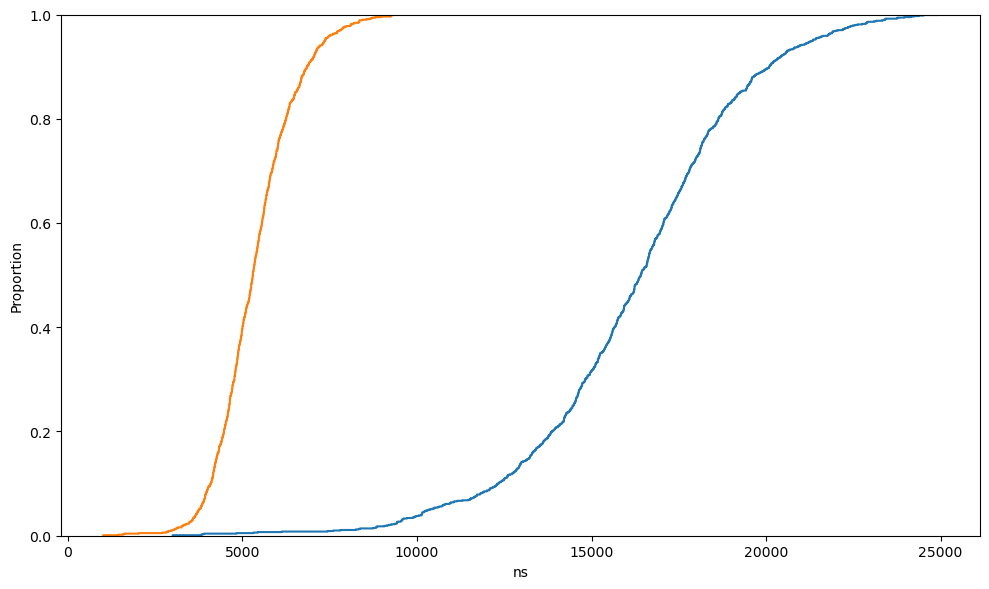

In [4]:
# pd.options.plotting.backend = 'plotly'

iarr = 1024
timer = 'cgt'

filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_filt'
tm_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}'
tf_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_tf'


import seaborn as sns
import matplotlib.pyplot as plt

# tm_list = sorted(tm_folder_path.iterdir())
# parts = []
# for file_idx, path in enumerate(tm_list):
#     d = pd.read_csv(path, header=None, names=["rank", "ns"])
#     d["file_idx"] = file_idx
#     parts.append(d)
# tm_all = pd.concat(parts, ignore_index=True)
# quantile = np.quantile(tm_all['ns'], 0.995)
# tm_all = tm_all[tm_all['ns'] < quantile]


tm_df = pd.read_csv(os.path.join(filt_folder_path,'met.csv'),header=None)
tm_df.columns = ['ns']
quantile_val = tm_df['ns'].quantile(0.995)
tm_df = tm_df[tm_df['ns'] <= quantile_val]

tf_df = pd.read_csv(os.path.join(filt_folder_path,'tf.csv'),header=None)
tf_df.columns = ['ns']
quantile_val = tf_df['ns'].quantile(0.995)
tf_df = tf_df[tf_df['ns'] <= quantile_val]

fig, ax = plt.subplots(figsize=(10, 6))
# sns.histplot(data=tm_df, x="ns", bins=100, kde=True, ax=ax)
# sns.histplot(data=tf_df, x='ns', bins=100, kde=True, ax=ax)

tm_df_sampled = tm_df.sample(n=1000)
tf_df_sampled = tf_df.sample(n=1000)
# sns.kdeplot(data=tm_df_sampled, x="ns", fill=True, ax=ax)
# sns.kdeplot(data=tf_df_sampled, x='ns', fill=True, ax=ax)

sns.ecdfplot(data=tm_df_sampled, x="ns", ax=ax)
sns.ecdfplot(data=tf_df_sampled, x='ns', ax=ax)

# ax.set_title(f"tm ns pooled ({len(tm_list)} files, n={len(tm_all)})")
plt.tight_layout()
plt.show()

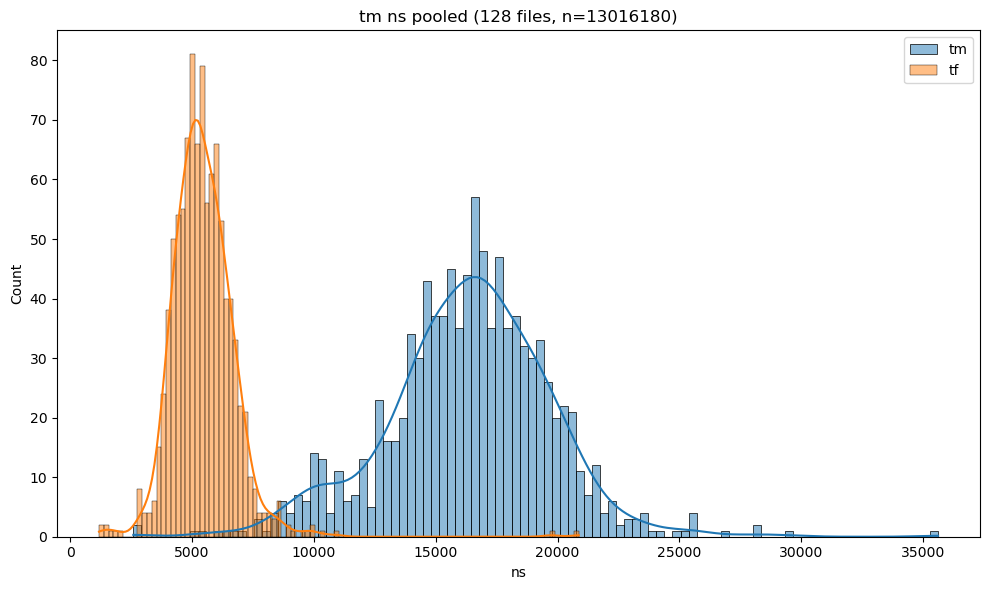

In [5]:
# pd.options.plotting.backend = 'plotly'

iarr = 1024
timer = 'papi'

filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_filt'
tm_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}'
tf_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_tf'


import seaborn as sns
import matplotlib.pyplot as plt

tm_list = sorted(tm_folder_path.iterdir())
parts = []
for file_idx, path in enumerate(tm_list):
    d = pd.read_csv(path, header=None, names=["rank", "ns"])
    d["file_idx"] = file_idx
    parts.append(d)
tm_all = pd.concat(parts, ignore_index=True)

quantile = np.quantile(tm_all['ns'], 0.995)
tm_all = tm_all[tm_all['ns'] < quantile]


tm_df = pd.read_csv(os.path.join(filt_folder_path,'met.csv'), header=None)
tm_df.columns = ['ns']

tf_df = pd.read_csv(os.path.join(filt_folder_path,'tf.csv'), header=None)
tf_df.columns = ['ns']


quantile_val


tm_df_sampled = tm_df.sample(n=1000)
tf_df_sampled = tf_df.sample(n=1000)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=tm_df_sampled, x="ns", bins=100, kde=True, ax=ax, label='tm')
sns.histplot(data=tf_df_sampled, x="ns", bins=100, kde=True, ax=ax, label='tf')

# sns.ecdfplot(data=tm_df_sampled, x='ns', label='tm')
# sns.ecdfplot(data=tf_df_sampled, x='ns', label='tf')

ax.set_title(f"tm ns pooled ({len(tm_list)} files, n={len(tm_all)})")
plt.legend()
plt.tight_layout()
plt.show()

<Axes: ylabel='Density'>

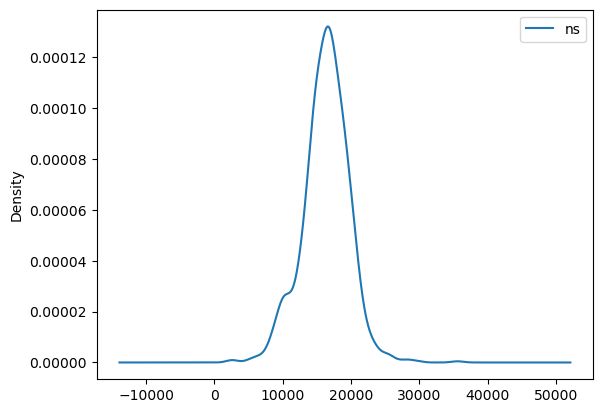

In [6]:
tm_df_sampled.plot.kde()